### 인사이트 도출을 위한 시각화

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import kruskal, spearmanr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
import scikit_posthocs as sp

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 한글 폰트
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# ============================================================
# 공통 색상 팔레트
#   그룹A(상온) = 파랑  그룹C(고온) = 빨강
#   Re/EOL기준  = 빨강  Rct/주의기준 = 주황
#   정상구간    = 초록  보조/회색    = #90A4AE
# ============================================================
GROUP_COLORS = {
    'A': '#2196F3',
    'C': '#E53935',
    'F': '#9C27B0', 'G': '#9C27B0',
    'H': '#9C27B0', 'I': '#9C27B0',
}
BATTERY_COLORS = {
    'B0005': '#1565C0',
    'B0006': '#2196F3',
    'B0007': '#64B5F6',
    'B0018': '#90CAF9',
    'B0029': '#E53935',
    'B0030': '#EF9A9A',
    'B0031': '#FF9800',
    'B0032': '#FFCC80',
}

print("=" * 60)
print("라이브러리 로드 완료")
print("=" * 60)


라이브러리 로드 완료


In [2]:
# ============================================================
# 데이터 로드
# ============================================================
base_path = 'data/new_data'

# ── 방전 데이터 (그룹별 CSV 직접 로드)
df_A = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_C = pd.read_csv(os.path.join(base_path, 'df_C_comparison.csv'))

# 이상 배터리 (G, H, I 파일 합산 — F 없을 경우 제외)
anom_files = {
    'F': 'df_group_F.csv', 'G': 'df_group_G.csv',
    'H': 'df_group_H.csv', 'I': 'df_group_I.csv',
}
anom_parts = []
for grp, fname in anom_files.items():
    fpath = os.path.join(base_path, fname)
    if os.path.exists(fpath):
        anom_parts.append(pd.read_csv(fpath))
df_anomaly = pd.concat(anom_parts, ignore_index=True) if anom_parts else pd.DataFrame()

# ── 임피던스 데이터
df_imp_A = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
df_imp_C = pd.read_csv(os.path.join(base_path, 'df_imp_C_comparison.csv'))

# impedance_cycle_no → imp_cycle_no 통일 (실제 컬럼명 대응)
for _df in [df_imp_A, df_imp_C]:
    if 'imp_cycle_no' not in _df.columns:
        if 'impedance_cycle_no' in _df.columns:
            _df['imp_cycle_no'] = _df['impedance_cycle_no']
        else:
            _df.sort_values(['battery_id', 'test_id'], inplace=True)
            _df['imp_cycle_no'] = _df.groupby('battery_id').cumcount() + 1

# ── ML 데이터셋 (RUL 구간 분석용)
df_rul = pd.read_csv(os.path.join(base_path, 'df_ml_dataset.csv'))
df_rul = df_rul.dropna(subset=['Re_mean', 'RUL'])

# ── valid 행 필터
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
df_C_valid = df_C[df_C['cap_flag'] == 'valid'].copy()

# SOH_diff 계산 (열화 속도 분석용)
for _df in [df_A_valid, df_C_valid]:
    _df['SOH_diff'] = _df.groupby('battery_id')['SOH_relative'].diff().fillna(0)

# ── EOL 헬퍼 함수
def get_eol(df, threshold=70):
    eol = (
        df[df['SOH_nominal'] < threshold]
        .groupby('battery_id')['discharge_cycle_raw']
        .min()
        .reset_index()
        .rename(columns={'discharge_cycle_raw': 'eol_cycle'})
    )
    eol['group'] = eol['battery_id'].map(
        df.groupby('battery_id')['group'].first().to_dict()
    )
    eol['temperature'] = eol['battery_id'].map(
        df.groupby('battery_id')['ambient_temperature'].first().to_dict()
    )
    return eol

eol_A   = get_eol(df_A_valid)
eol_C   = get_eol(df_C_valid)
eol_all = pd.concat([eol_A, eol_C], ignore_index=True)

print("=" * 55)
print("데이터 로드 완료")
print("=" * 55)
print(f"df_A_valid  : {len(df_A_valid)}행  {df_A_valid['battery_id'].nunique()}개 배터리")
print(f"df_C_valid  : {len(df_C_valid)}행  {df_C_valid['battery_id'].nunique()}개 배터리")
print(f"df_imp_A    : {len(df_imp_A)}행")
print(f"df_imp_C    : {len(df_imp_C)}행")
print(f"df_anomaly  : {len(df_anomaly)}행  그룹={sorted(df_anomaly['group'].unique()) if len(df_anomaly) else '없음'}")
print(f"df_rul(ML)  : {len(df_rul)}행")
print(f"\n배터리별 EOL 사이클:")
print(eol_all.to_string(index=False))


데이터 로드 완료
df_A_valid  : 636행  4개 배터리
df_C_valid  : 160행  4개 배터리
df_imp_A    : 887행
df_imp_C    : 68행
df_anomaly  : 1154행  그룹=['F', 'G', 'H', 'I']
df_rul(ML)  : 430행

배터리별 EOL 사이클:
battery_id  eol_cycle group  temperature
     B0005        125     A           24
     B0006        109     A           24
     B0018         97     A           24


# EDA

# EDA 3. SOH 열화 곡선 비교 (그룹 A vs C)

- 파란 선 / 그룹A (상온 24°C)
- 빨간 선 / 그룹C (고온 43°C)
- 빨간 점선 / EOL 기준 (SOH 80%)
- 주황 점선 / 주의 기준 (SOH 90%)


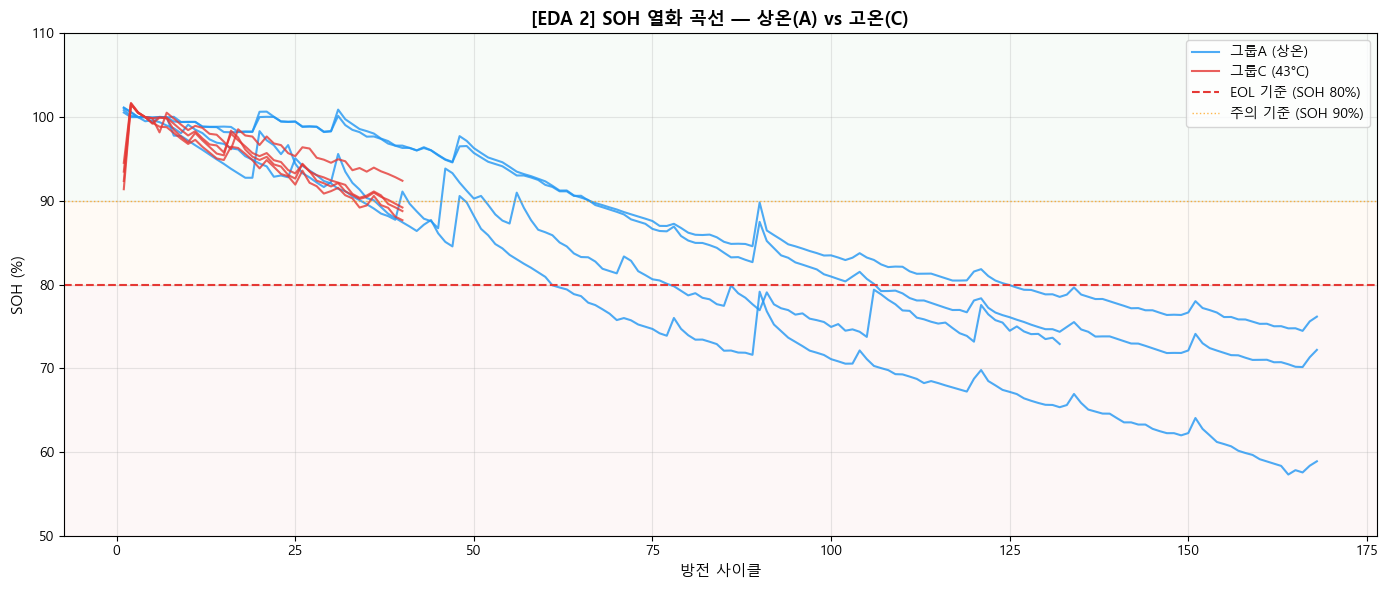

[저장] eda3_soh_curve.png


In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id'] == bid]
    ax.plot(b['discharge_cycle_raw'], b['SOH_relative'],
            linewidth=1.5, color=GROUP_COLORS['A'], alpha=0.8,
            label='그룹A (상온)' if bid == sorted(df_A_valid['battery_id'].unique())[0] else '_nolegend_')

for bid in sorted(df_C_valid['battery_id'].unique()):
    b = df_C_valid[df_C_valid['battery_id'] == bid]
    ax.plot(b['discharge_cycle_raw'], b['SOH_relative'],
            linewidth=1.5, color=GROUP_COLORS['C'], alpha=0.8,
            label='그룹C (43°C)' if bid == sorted(df_C_valid['battery_id'].unique())[0] else '_nolegend_')

ax.axhline(y=80, color='#E53935', linestyle='--', linewidth=1.5, label='EOL 기준 (SOH 80%)')
ax.axhline(y=90, color='#FF9800', linestyle=':', linewidth=1, label='주의 기준 (SOH 90%)', alpha=0.7)
ax.axhspan(0,  80,  alpha=0.04, color='#E53935')
ax.axhspan(80, 90,  alpha=0.04, color='#FF9800')
ax.axhspan(90, 110, alpha=0.04, color='#4CAF50')

ax.set_xlabel('방전 사이클', fontsize=11)
ax.set_ylabel('SOH (%)', fontsize=11)
ax.set_title('[EDA 2] SOH 열화 곡선 — 상온(A) vs 고온(C)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(50, 110)
plt.tight_layout()
plt.savefig('eda3_soh_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda3_soh_curve.png')


# EDA 4. Re·Rct 추이 — 내부저항 변화

- SOH (%) : 배터리 고유 색상
- Re (빨강 실선) : 전해질 저항
- Rct (주황 점선) : 전하전달 저항


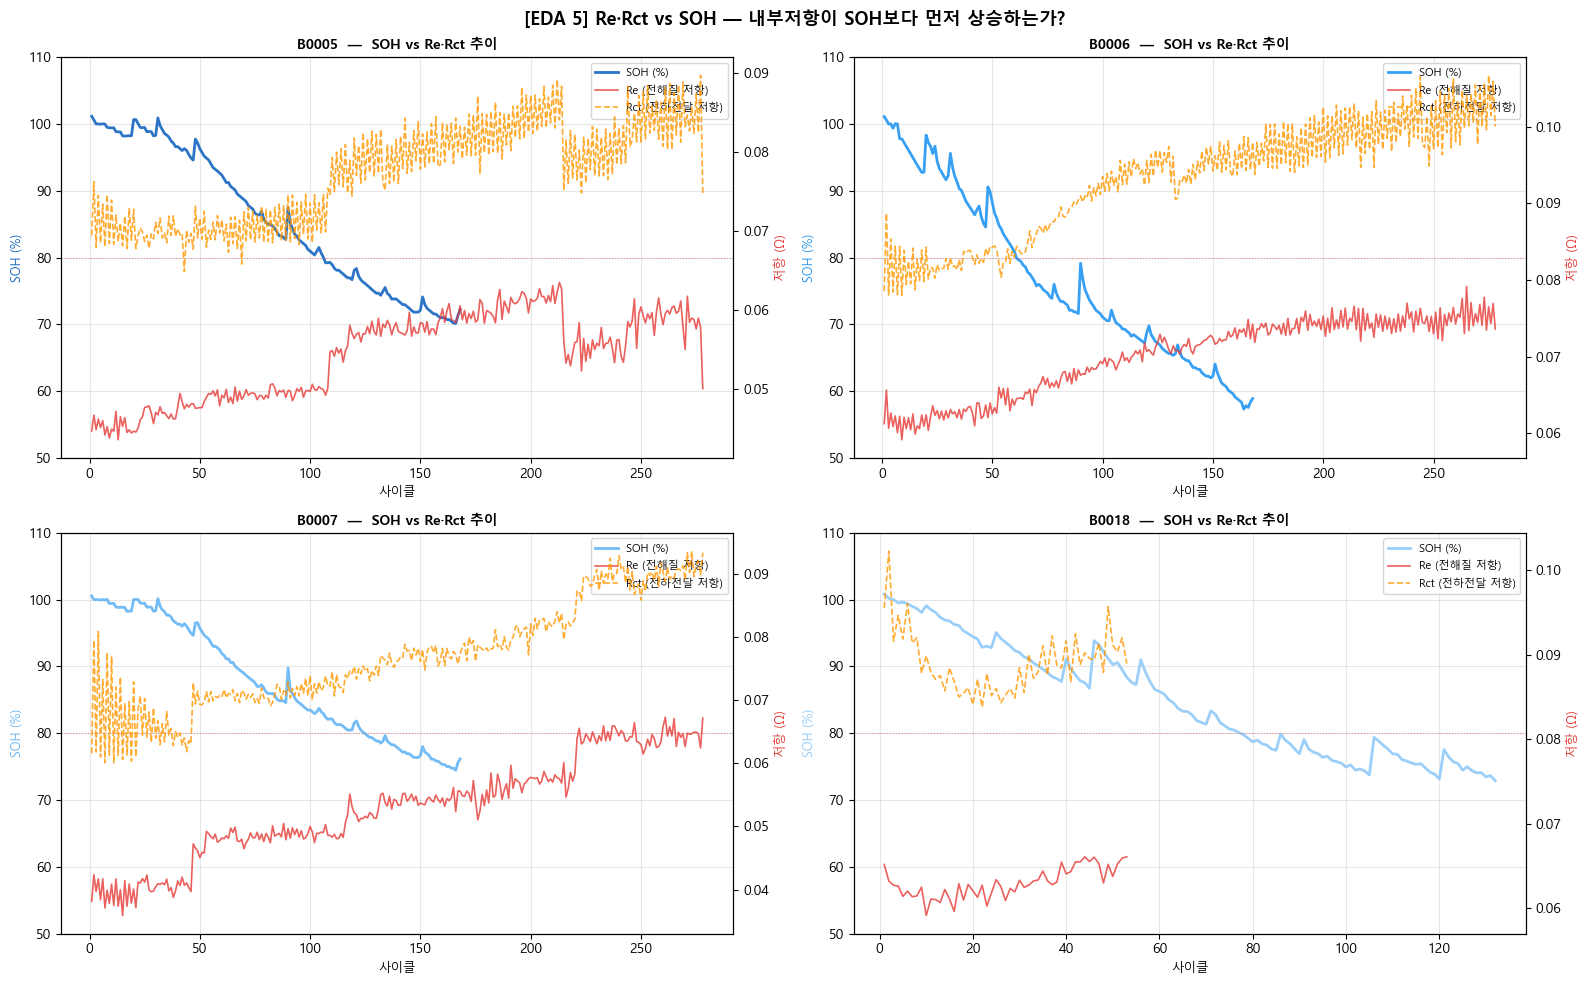

[저장] eda4_re_rct_vs_soh.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, bid in enumerate(sorted(df_imp_A['battery_id'].unique())):
    row, col = idx // 2, idx % 2
    ax = axes[row][col]

    b_imp = df_imp_A[df_imp_A['battery_id'] == bid].copy()
    b_dis = df_A_valid[df_A_valid['battery_id'] == bid].copy()
    color = BATTERY_COLORS.get(bid, '#90A4AE')

    ax2 = ax.twinx()
    ax2.plot(b_imp['imp_cycle_no'], b_imp['Re'],
             color='#E53935', linewidth=1.2, alpha=0.8, label='Re (전해질 저항)')
    ax2.plot(b_imp['imp_cycle_no'], b_imp['Rct'],
             color='#FF9800', linewidth=1.2, alpha=0.8, linestyle='--', label='Rct (전하전달 저항)')
    ax2.set_ylabel('저항 (Ω)', color='#E53935', fontsize=9)

    ax.plot(b_dis['discharge_cycle_raw'], b_dis['SOH_relative'],
            color=color, linewidth=2, alpha=0.9, label='SOH (%)')
    ax.axhline(y=80, color='#E53935', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_ylabel('SOH (%)', color=color, fontsize=9)
    ax.set_xlabel('사이클', fontsize=9)
    ax.set_title(f'{bid}  —  SOH vs Re·Rct 추이', fontsize=10, fontweight='bold')
    ax.set_ylim(50, 110)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('[EDA 5] Re·Rct vs SOH — 내부저항이 SOH보다 먼저 상승하는가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda4_re_rct_vs_soh.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda4_re_rct_vs_soh.png')


# EDA 5. Re·Rct vs SOH 산점도

매핑된 행 수: 557


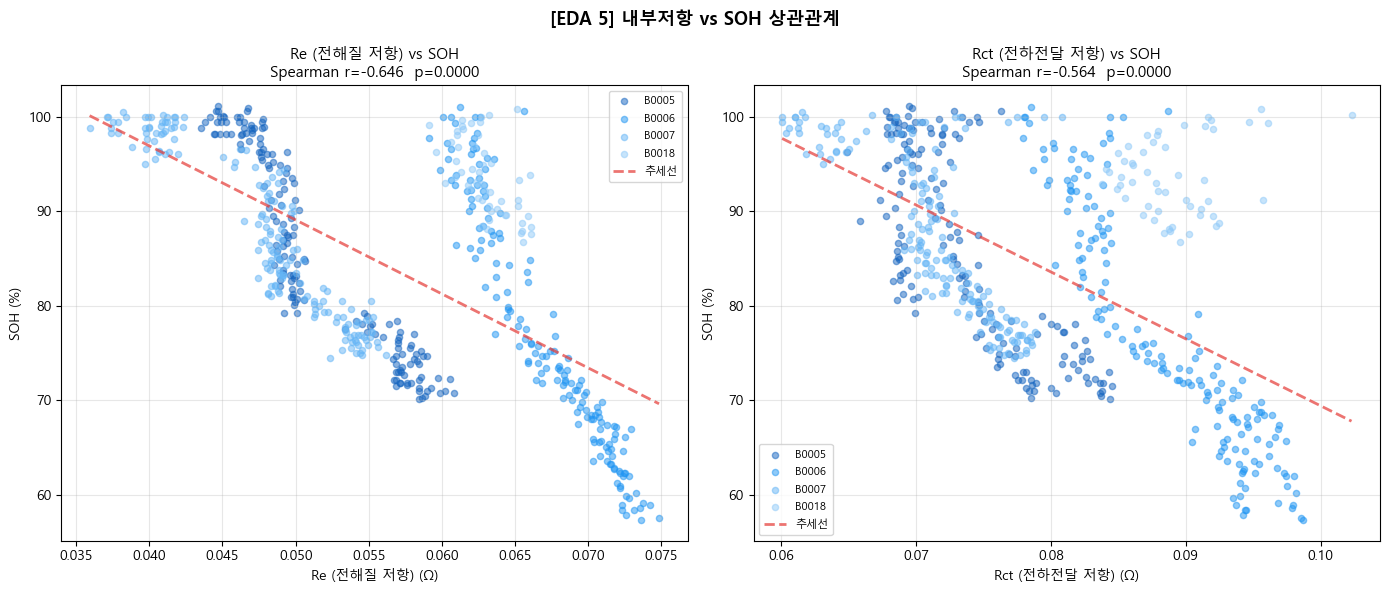

[저장] eda5_correlation.png


In [5]:
# cycle_rank 기반 매핑 (imp vs discharge 사이클 수 다를 수 있음)
# dis_r에도 Re, Rct가 있으므로 imp 쪽만 선택해서 충돌 방지
imp_r = df_imp_A.copy()
imp_r['cycle_rank'] = imp_r.groupby('battery_id')['imp_cycle_no'].rank(method='first').astype(int)

dis_r = df_A_valid[['battery_id', 'discharge_cycle_raw', 'SOH_relative']].copy()
dis_r['cycle_rank'] = dis_r.groupby('battery_id')['discharge_cycle_raw'].rank(method='first').astype(int)

merged = dis_r.merge(
    imp_r[['battery_id', 'cycle_rank', 'Re', 'Rct']],
    on=['battery_id', 'cycle_rank'], how='inner'
).dropna(subset=['SOH_relative', 'Re', 'Rct'])

print(f"매핑된 행 수: {len(merged)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, name in zip(axes, ['Re', 'Rct'], ['Re (전해질 저항)', 'Rct (전하전달 저항)']):
    for bid in sorted(merged['battery_id'].unique()):
        b = merged[merged['battery_id'] == bid]
        ax.scatter(b[col], b['SOH_relative'],
                   alpha=0.5, s=20, color=BATTERY_COLORS.get(bid, '#90A4AE'), label=bid)

    x, y = merged[col].values, merged['SOH_relative'].values
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='#E53935', linestyle='--',
            linewidth=2, alpha=0.7, label='추세선')

    r, p = spearmanr(x, y)
    ax.set_xlabel(f'{name} (Ω)', fontsize=10)
    ax.set_ylabel('SOH (%)', fontsize=10)
    ax.set_title(f'{name} vs SOH\nSpearman r={r:.3f}  p={p:.4f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('[EDA 5] 내부저항 vs SOH 상관관계', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda5_correlation.png')


# EDA 6. 그룹별 수명 비교

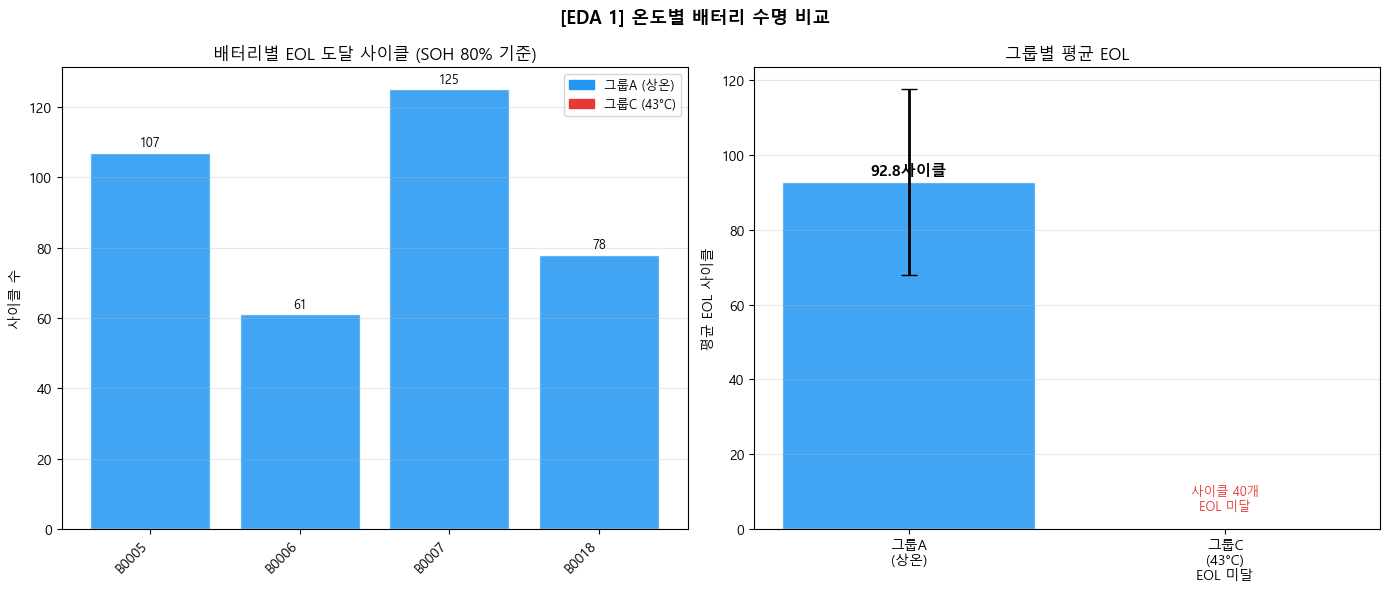

[저장] eda6_lifetime_comparison.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

eol_data = []
for df_grp, grp_label in [(df_A_valid, 'A'), (df_C_valid, 'C')]:
    for bid in df_grp['battery_id'].unique():
        b     = df_grp[df_grp['battery_id'] == bid]
        eol   = b[b['SOH_relative'] < 80]['discharge_cycle_raw'].min()
        total = b['discharge_cycle_raw'].max()
        temp  = b['ambient_temperature'].mode()[0]
        eol_data.append({'battery_id': bid, 'group': grp_label,
                          'eol_cycle': eol, 'total_cycle': total, 'temperature': temp})

eol_df   = pd.DataFrame(eol_data)
eol_A_np = eol_df[eol_df['group'] == 'A']['eol_cycle'].dropna().values
eol_C_np = eol_df[eol_df['group'] == 'C']['eol_cycle'].dropna().values

colors_bar = [GROUP_COLORS[g] for g in eol_df['group']]
bars = axes[0].bar(eol_df['battery_id'], eol_df['eol_cycle'],
                   color=colors_bar, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, eol_df['eol_cycle']):
    if pd.notna(val):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1, f'{int(val)}',
                     ha='center', va='bottom', fontsize=9)

axes[0].set_title('배터리별 EOL 도달 사이클 (SOH 80% 기준)')
axes[0].set_ylabel('사이클 수')
axes[0].set_xticklabels(eol_df['battery_id'], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(handles=[
    mpatches.Patch(color=GROUP_COLORS['A'], label='그룹A (상온)'),
    mpatches.Patch(color=GROUP_COLORS['C'], label='그룹C (43°C)'),
], fontsize=9)

if len(eol_A_np) > 0:
    axes[1].bar(['그룹A\n(상온)'], [np.mean(eol_A_np)],
                color=GROUP_COLORS['A'], alpha=0.85, edgecolor='white',
                yerr=[np.std(eol_A_np)], capsize=6, error_kw={'linewidth': 2})
    axes[1].text(0, np.mean(eol_A_np) + 2, f'{np.mean(eol_A_np):.1f}사이클',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['그룹C\n(43°C)\nEOL 미달'], [0],
            color=GROUP_COLORS['C'], alpha=0.4, edgecolor='white')
axes[1].text(1, 5, '사이클 40개\nEOL 미달', ha='center',
             fontsize=9, color=GROUP_COLORS['C'])
axes[1].set_ylabel('평균 EOL 사이클')
axes[1].set_title('그룹별 평균 EOL')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('[EDA 1] 온도별 배터리 수명 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda6_lifetime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda6_lifetime_comparison.png')


# EDA 7. 이상 배터리 패턴 (그룹 F·G·H·I)

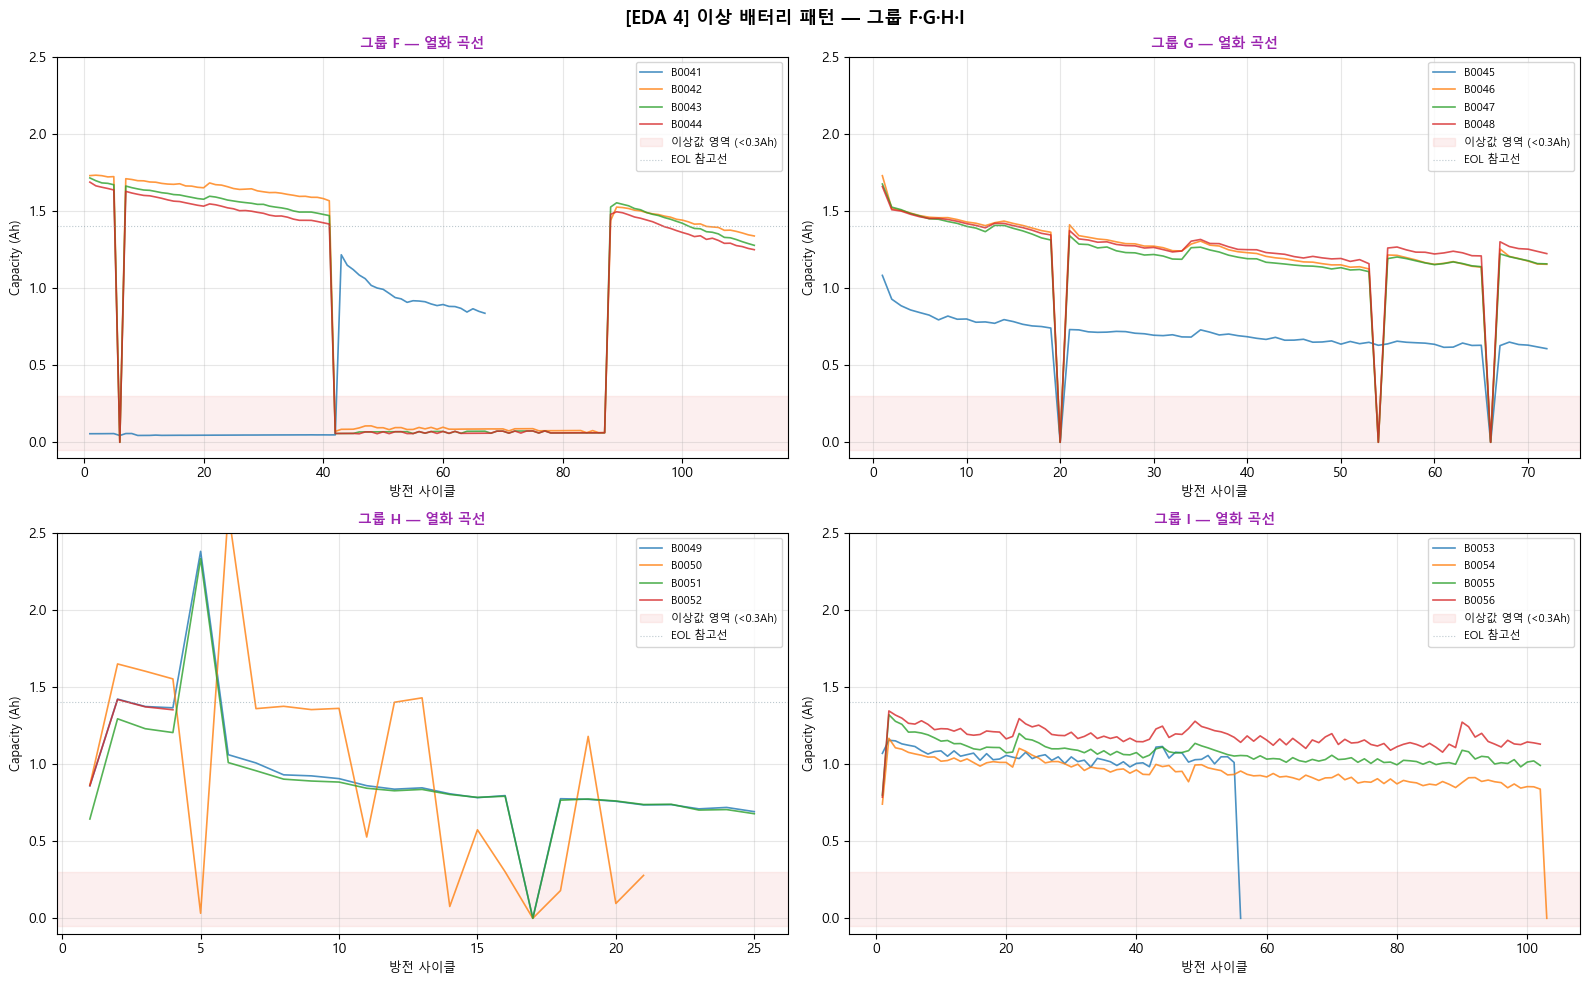

[저장] eda7_anomaly_pattern.png


In [7]:
if len(df_anomaly) == 0:
    print("df_anomaly 없음 — data/new_data 안의 df_group_F/G/H/I.csv 확인")
else:
    df_anom = df_anomaly.copy()
    df_anom['Capacity'] = pd.to_numeric(df_anom['Capacity'], errors='coerce')

    avail_groups = sorted(df_anom['group'].unique())
    n = len(avail_groups)
    fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(16, 5 * ((n + 1) // 2)))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, grp in enumerate(avail_groups):
        ax = axes[idx]
        grp_data = df_anom[df_anom['group'] == grp]
        for bid in sorted(grp_data['battery_id'].unique()):
            b = grp_data[grp_data['battery_id'] == bid]
            ax.plot(b['discharge_cycle_raw'], b['Capacity'],
                    linewidth=1.2, alpha=0.8, label=bid)
        ax.axhspan(-0.05, 0.3, alpha=0.08, color='#E53935', label='이상값 영역 (<0.3Ah)')
        ax.axhline(y=1.4, color='#90A4AE', linestyle=':', linewidth=0.8, label='EOL 참고선', alpha=0.6)
        ax.set_title(f'그룹 {grp} — 열화 곡선', fontsize=10, fontweight='bold',
                     color=GROUP_COLORS.get(grp, '#333333'))
        ax.set_xlabel('방전 사이클', fontsize=9)
        ax.set_ylabel('Capacity (Ah)', fontsize=9)
        ax.set_ylim(-0.1, 2.5)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle('[EDA 4] 이상 배터리 패턴 — 그룹 F·G·H·I',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda7_anomaly_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] eda7_anomaly_pattern.png')


# EDA 8. 상관관계 히트맵

히트맵 데이터: 305행


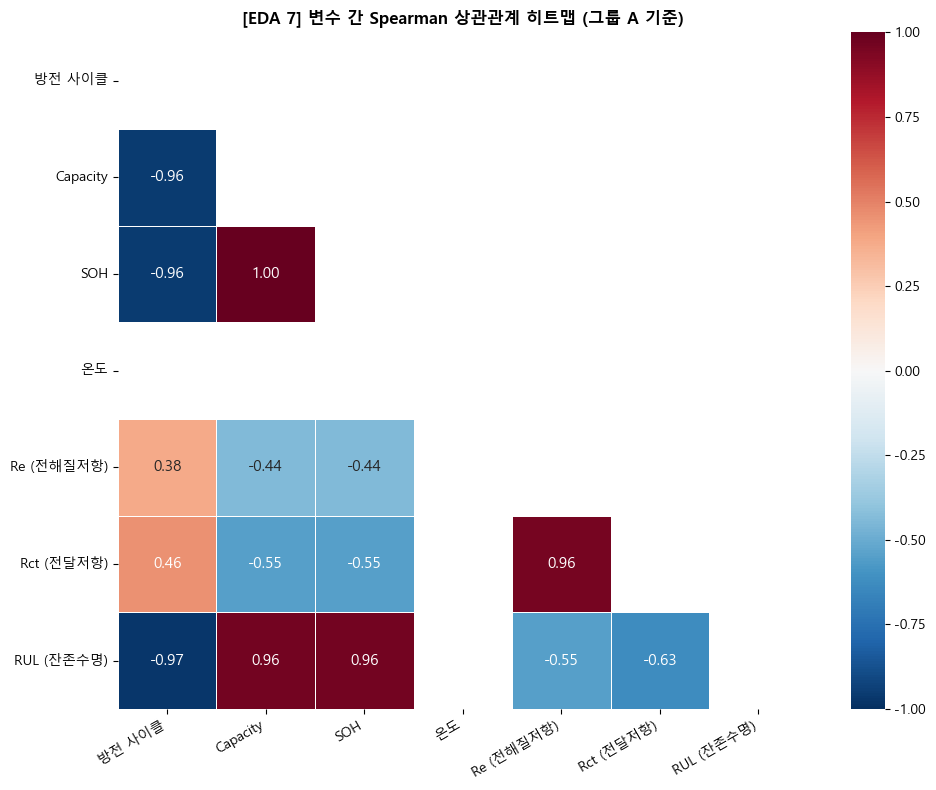

[저장] eda8_correlation_heatmap.png


In [8]:
# imp_cycle_no 기반으로 discharge_cycle_raw에 근사 매핑
imp_mapped = df_imp_A.copy()
imp_mapped['discharge_cycle_raw'] = ((imp_mapped['imp_cycle_no'] + 1) // 2)

imp_agg = (
    imp_mapped.groupby(['battery_id', 'discharge_cycle_raw'])[['Re', 'Rct']]
    .mean().reset_index()
    .rename(columns={'Re': 'Re_val', 'Rct': 'Rct_val'})
)

heatmap_df = df_A_valid.merge(imp_agg, on=['battery_id', 'discharge_cycle_raw'], how='left')
heatmap_df['Re']  = heatmap_df['Re_val']
heatmap_df['Rct'] = heatmap_df['Rct_val']

corr_cols = ['discharge_cycle_raw', 'Capacity', 'SOH_nominal',
             'ambient_temperature', 'Re', 'Rct', 'RUL']
# RUL 없으면 제외
corr_cols = [c for c in corr_cols if c in heatmap_df.columns]
heatmap_df = heatmap_df[corr_cols].dropna()
print(f"히트맵 데이터: {len(heatmap_df)}행")

corr_matrix = heatmap_df.corr(method='spearman')
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 11})

korean_labels = {
    'discharge_cycle_raw': '방전 사이클', 'Capacity': 'Capacity',
    'SOH_nominal': 'SOH', 'ambient_temperature': '온도',
    'Re': 'Re (전해질저항)', 'Rct': 'Rct (전달저항)', 'RUL': 'RUL (잔존수명)',
}
ax.set_xticklabels([korean_labels.get(c, c) for c in corr_matrix.columns],
                   rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([korean_labels.get(c, c) for c in corr_matrix.index],
                   rotation=0, fontsize=10)
ax.set_title('[EDA 7] 변수 간 Spearman 상관관계 히트맵 (그룹 A 기준)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda8_correlation_heatmap.png')


매핑된 행 수: 557

Re (전해질 저항): r=-0.6461  p=0.000000  → 유의미 / 음의 상관 (저항↑ → SOH↓) / 강함
Rct (전하전달 저항): r=-0.5639  p=0.000000  → 유의미 / 음의 상관 (저항↑ → SOH↓) / 강함

  B0005: Re r=-0.949(p=0.0000)  Rct r=-0.751(p=0.0000)
  B0006: Re r=-0.965(p=0.0000)  Rct r=-0.909(p=0.0000)
  B0007: Re r=-0.921(p=0.0000)  Rct r=-0.769(p=0.0000)
  B0018: Re r=-0.634(p=0.0000)  Rct r=0.029(p=0.8361)


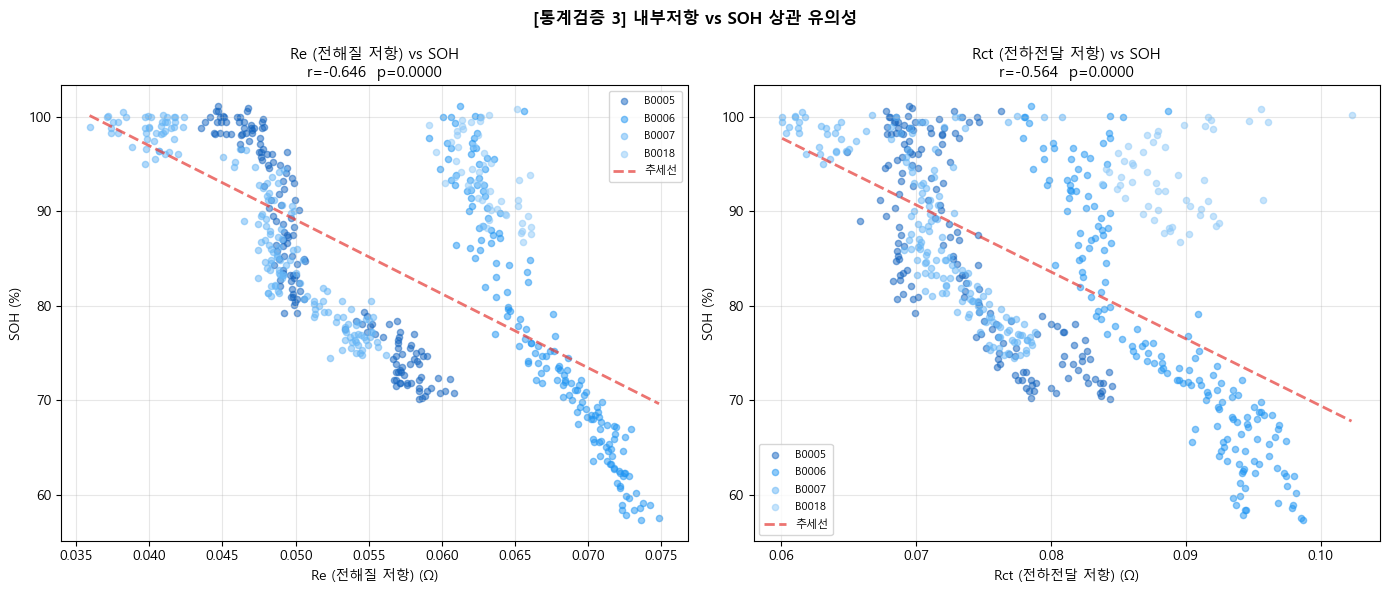

[저장] stat3_correlation_test.png


In [9]:
# ============================================================
# [통계검증 3] Re·Rct vs SOH 상관 유의성 (Spearman)
# ============================================================
imp_r2 = df_imp_A.copy()
imp_r2['cycle_rank'] = imp_r2.groupby('battery_id')['imp_cycle_no'].rank(method='first').astype(int)

dis_r2 = df_A_valid[['battery_id', 'discharge_cycle_raw', 'SOH_relative']].copy()
dis_r2['cycle_rank'] = dis_r2.groupby('battery_id')['discharge_cycle_raw'].rank(method='first').astype(int)

merged2 = dis_r2.merge(
    imp_r2[['battery_id', 'cycle_rank', 'Re', 'Rct']],
    on=['battery_id', 'cycle_rank'], how='inner'
).dropna(subset=['SOH_relative', 'Re', 'Rct'])

print(f"매핑된 행 수: {len(merged2)}\n")

for col, name in [('Re', 'Re (전해질 저항)'), ('Rct', 'Rct (전하전달 저항)')]:
    r, p = spearmanr(merged2[col], merged2['SOH_relative'])
    sig  = "유의미" if p < 0.05 else "비유의"
    direction = "음의 상관 (저항↑ → SOH↓)" if r < 0 else "양의 상관"
    strength  = "매우 강함" if abs(r) >= 0.7 else "강함" if abs(r) >= 0.5 else "중간"
    print(f"{name}: r={r:.4f}  p={p:.6f}  → {sig} / {direction} / {strength}")

print()
for bid in sorted(merged2['battery_id'].unique()):
    b = merged2[merged2['battery_id'] == bid]
    if len(b) > 3:
        r_re,  p_re  = spearmanr(b['Re'],  b['SOH_relative'])
        r_rct, p_rct = spearmanr(b['Rct'], b['SOH_relative'])
        print(f"  {bid}: Re r={r_re:.3f}(p={p_re:.4f})  Rct r={r_rct:.3f}(p={p_rct:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, name in zip(axes, ['Re', 'Rct'], ['Re (전해질 저항)', 'Rct (전하전달 저항)']):
    for bid in sorted(merged2['battery_id'].unique()):
        b = merged2[merged2['battery_id'] == bid]
        ax.scatter(b[col], b['SOH_relative'],
                   alpha=0.5, s=20, color=BATTERY_COLORS.get(bid, '#90A4AE'), label=bid)
    x, y = merged2[col].values, merged2['SOH_relative'].values
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='#E53935',
            linestyle='--', linewidth=2, alpha=0.7, label='추세선')
    r, p = spearmanr(x, y)
    ax.set_xlabel(f'{name} (Ω)', fontsize=10)
    ax.set_ylabel('SOH (%)', fontsize=10)
    ax.set_title(f'{name} vs SOH\nr={r:.3f}  p={p:.4f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('[통계검증 3] 내부저항 vs SOH 상관 유의성', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stat3_correlation_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat3_correlation_test.png')


# 추가 EDA

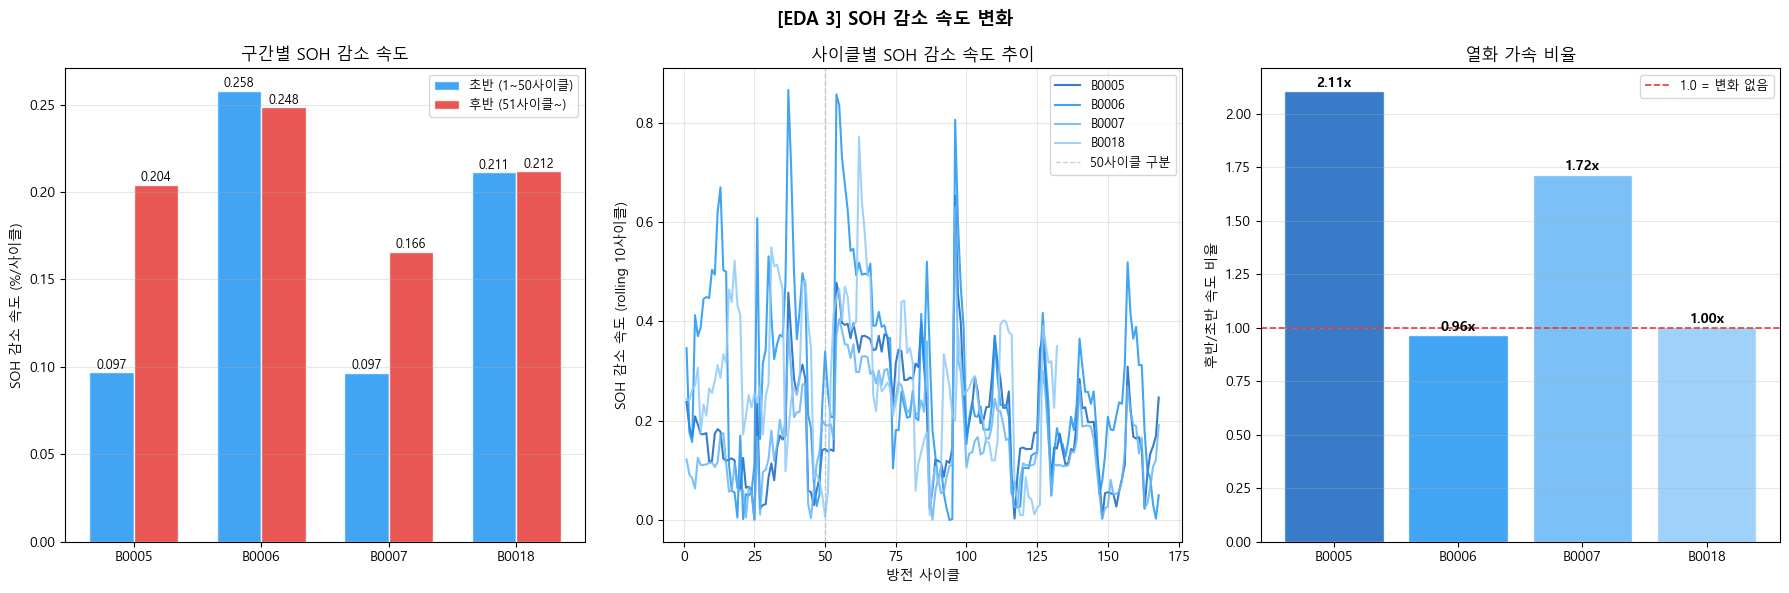

[저장] extra_eda_speed.png


In [10]:
# ============================================================
# [추가 EDA 1] SOH 감소 속도 변화 패턴
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

speed_data = []
for bid in sorted(df_A_valid['battery_id'].unique()):
    b     = df_A_valid[df_A_valid['battery_id'] == bid].copy()
    early = b[b['discharge_cycle_raw'] <= 50]['SOH_diff'].mean()
    late  = b[b['discharge_cycle_raw'] >  50]['SOH_diff'].mean()
    speed_data.append({'battery_id': bid, 'early': early, 'late': late})

speed_df = pd.DataFrame(speed_data)
x, w = range(len(speed_df)), 0.35

bars1 = axes[0].bar([i - w/2 for i in x], speed_df['early'].abs(),
                    width=w, label='초반 (1~50사이클)', color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar([i + w/2 for i in x], speed_df['late'].abs(),
                    width=w, label='후반 (51사이클~)',  color='#E53935', alpha=0.85, edgecolor='white')

for bar, val in zip(bars1, speed_df['early'].abs()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=9)
for bar, val in zip(bars2, speed_df['late'].abs()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=9)

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(speed_df['battery_id'])
axes[0].set_ylabel('SOH 감소 속도 (%/사이클)')
axes[0].set_title('구간별 SOH 감소 속도')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id'] == bid].copy()
    rolling = b['SOH_diff'].rolling(window=10, center=True, min_periods=1).mean()
    axes[1].plot(b['discharge_cycle_raw'], rolling.abs(),
                 color=BATTERY_COLORS.get(bid, '#90A4AE'), linewidth=1.5, label=bid, alpha=0.85)

axes[1].axvline(x=50, color='#90A4AE', linestyle='--', linewidth=1, alpha=0.5, label='50사이클 구분')
axes[1].set_xlabel('방전 사이클')
axes[1].set_ylabel('SOH 감소 속도 (rolling 10사이클)')
axes[1].set_title('사이클별 SOH 감소 속도 추이')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

speed_df['accel_ratio'] = speed_df['late'].abs() / speed_df['early'].abs()
colors_bar = [BATTERY_COLORS.get(b, '#90A4AE') for b in speed_df['battery_id']]
bars3 = axes[2].bar(speed_df['battery_id'], speed_df['accel_ratio'],
                    color=colors_bar, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, speed_df['accel_ratio']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold')
axes[2].axhline(y=1.0, color='#E53935', linestyle='--', linewidth=1.2, label='1.0 = 변화 없음')
axes[2].set_ylabel('후반/초반 속도 비율')
axes[2].set_title('열화 가속 비율')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('[EDA 3] SOH 감소 속도 변화', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda_speed.png')


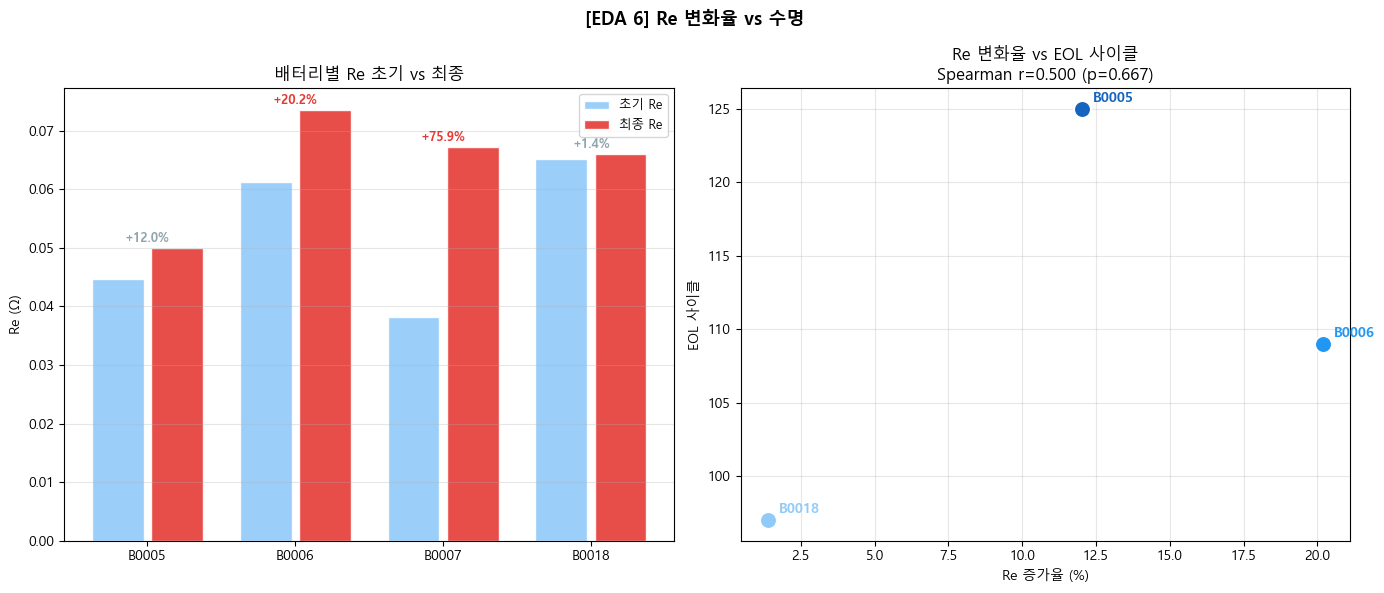

[저장] extra_eda_re_eol.png


In [11]:
# ============================================================
# [추가 EDA 2] Re 변화율 vs 수명
# eol_A는 Cell[11]에서 numpy array로 덮어쓰였으므로 다시 생성
# ============================================================
eol_A_df = get_eol(df_A_valid)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

re_agg = (
    df_imp_A.sort_values(['battery_id', 'imp_cycle_no'])
    .groupby('battery_id')['Re']
    .agg(re_init='first', re_final='last')
    .reset_index()
)
re_agg['re_rate'] = (re_agg['re_final'] - re_agg['re_init']) / re_agg['re_init'] * 100
re_df = re_agg.merge(eol_A_df[['battery_id', 'eol_cycle']], on='battery_id', how='left')

x3 = range(len(re_df))
axes[0].bar([i - 0.2 for i in x3], re_df['re_init'],
            width=0.35, label='초기 Re', color='#90CAF9', edgecolor='white', alpha=0.9)
axes[0].bar([i + 0.2 for i in x3], re_df['re_final'],
            width=0.35, label='최종 Re', color='#E53935', edgecolor='white', alpha=0.9)

for i, (bid, rate) in enumerate(zip(re_df['battery_id'], re_df['re_rate'])):
    axes[0].text(i, max(re_df['re_init'].iloc[i], re_df['re_final'].iloc[i]) + 0.001,
                 f'+{rate:.1f}%', ha='center', fontsize=9, fontweight='bold',
                 color='#E53935' if rate > 15 else '#90A4AE')

axes[0].set_xticks(list(x3))
axes[0].set_xticklabels(re_df['battery_id'])
axes[0].set_ylabel('Re (Ω)')
axes[0].set_title('배터리별 Re 초기 vs 최종')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

re_valid = re_df.dropna(subset=['eol_cycle'])
for _, row in re_valid.iterrows():
    color = BATTERY_COLORS.get(row['battery_id'], '#90A4AE')
    axes[1].scatter(row['re_rate'], row['eol_cycle'],
                    s=150, color=color, zorder=5, edgecolors='white', linewidth=1.5)
    axes[1].annotate(row['battery_id'], (row['re_rate'], row['eol_cycle']),
                     textcoords='offset points', xytext=(8, 5),
                     fontsize=10, fontweight='bold', color=color)

if len(re_valid) > 2:
    r, p = spearmanr(re_valid['re_rate'], re_valid['eol_cycle'])
    axes[1].set_title(f'Re 변화율 vs EOL 사이클\nSpearman r={r:.3f} (p={p:.3f})')
else:
    axes[1].set_title('Re 변화율 vs EOL 사이클\n(샘플 수 부족)')

axes[1].set_xlabel('Re 증가율 (%)')
axes[1].set_ylabel('EOL 사이클')
axes[1].grid(alpha=0.3)

fig.suptitle('[EDA 6] Re 변화율 vs 수명', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda_re_eol.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda_re_eol.png')


# SOH·Re 구간별 RUL 분포

  SOH ≥90%: 중앙값=79.0  n=107
  SOH 80~90%: 중앙값=44.0  n=98
  SOH 70~80%: 중앙값=1.5  n=164
  SOH <70%: 중앙값=0.0  n=61


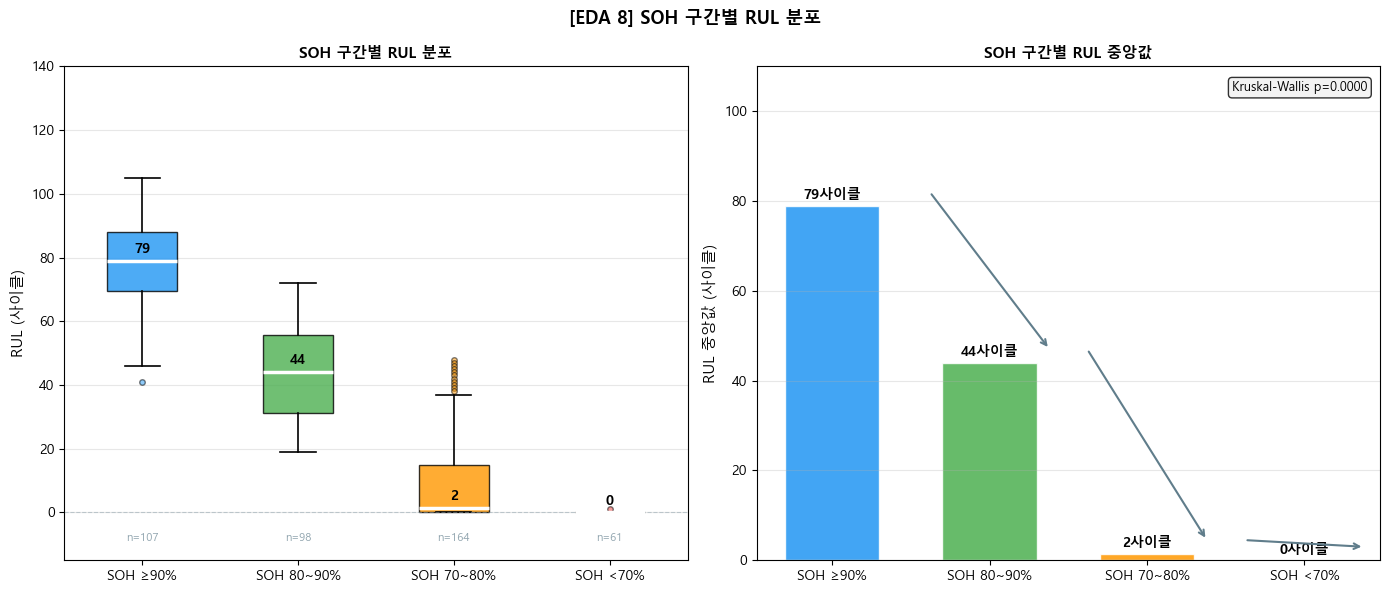

[저장] stat_soh_rul_stage.png


In [12]:
# ============================================================
# [통계 탐색] SOH 구간별 RUL 분포
# df_rul = df_ml_dataset (Re_mean / RUL 있는 행만)
# ============================================================
df_rul['soh_bin'] = pd.cut(
    df_rul['SOH_relative'],
    bins=[0, 70, 80, 90, 200],
    labels=['c_lt70', 'e_70_80', 'v_80_90', 'r_ge90']
)
df_rul['re_bin'] = pd.qcut(df_rul['Re_mean'], q=4,
                            labels=['re_q1', 're_q2', 're_q3', 're_q4'])

soh_order  = ['r_ge90', 'v_80_90', 'e_70_80', 'c_lt70']
soh_labels = ['SOH ≥90%', 'SOH 80~90%', 'SOH 70~80%', 'SOH <70%']
soh_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E53935']

re_order  = ['re_q1', 're_q2', 're_q3', 're_q4']
re_labels = ['Q1\n(Re 낮음)', 'Q2', 'Q3', 'Q4\n(Re 높음)']
re_colors = ['#2196F3', '#90CAF9', '#EF9A9A', '#E53935']

# 수치 요약
print("=" * 55)
for key, label in zip(soh_order, soh_labels):
    vals = df_rul[df_rul['soh_bin'] == key]['RUL'].values
    print(f"  {label}: 중앙값={np.median(vals):.1f}  n={len(vals)}")

data_soh = [df_rul[df_rul['soh_bin'] == k]['RUL'].values for k in soh_order]
meds_soh = [np.median(v) for v in data_soh]
ns_soh   = [len(v) for v in data_soh]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp = axes[0].boxplot(data_soh, labels=soh_labels, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2.5),
                     whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                     flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, color in zip(bp['boxes'], soh_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for flier, color in zip(bp['fliers'], soh_colors):
    flier.set_markerfacecolor(color)
for i, (med, n) in enumerate(zip(meds_soh, ns_soh)):
    axes[0].text(i+1, med + 2.5, f'{med:.0f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i+1, -9, f'n={n}', ha='center', fontsize=8, color='#90A4AE')
axes[0].set_ylabel('RUL (사이클)', fontsize=11)
axes[0].set_title('SOH 구간별 RUL 분포', fontsize=11, fontweight='bold')
axes[0].axhline(y=0, color='#90A4AE', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(-15, 140)

bars = axes[1].bar(soh_labels, meds_soh, color=soh_colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, val in zip(bars, meds_soh):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.0f}사이클', ha='center', fontsize=10, fontweight='bold')
for i in range(len(meds_soh) - 1):
    if meds_soh[i] > meds_soh[i+1]:
        axes[1].annotate('', xy=(i+1.38, meds_soh[i+1]+3), xytext=(i+0.62, meds_soh[i]+3),
                         arrowprops=dict(arrowstyle='->', color='#607D8B', lw=1.5))
stat_kw, p_kw = kruskal(*[v for v in data_soh if len(v) > 0])
axes[1].text(0.98, 0.97, f'Kruskal-Wallis p={p_kw:.4f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
axes[1].set_ylabel('RUL 중앙값 (사이클)', fontsize=11)
axes[1].set_title('SOH 구간별 RUL 중앙값', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 110)

plt.suptitle('[EDA 8] SOH 구간별 RUL 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_soh_rul_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_soh_rul_stage.png')


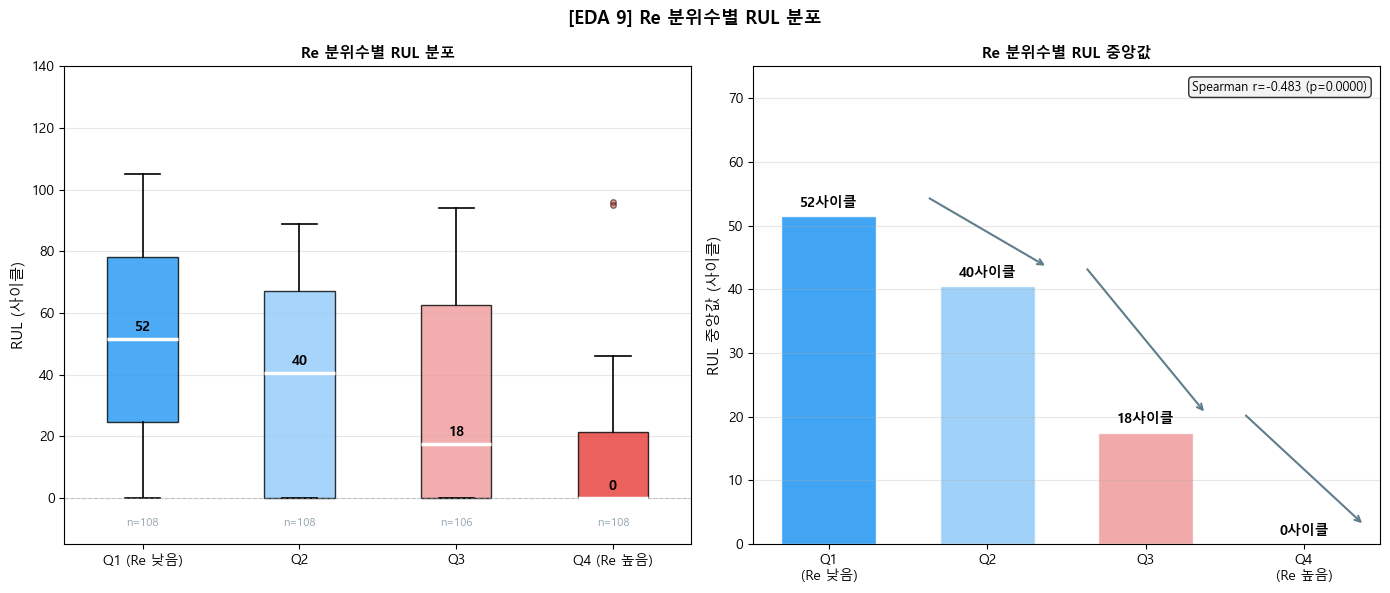

[저장] stat_re_rul_stage.png


In [13]:
data_re = [df_rul[df_rul['re_bin'] == k]['RUL'].values for k in re_order]
meds_re = [np.median(v) for v in data_re]
ns_re   = [len(v) for v in data_re]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp2 = axes[0].boxplot(data_re, labels=[l.replace('\n',' ') for l in re_labels],
                      patch_artist=True,
                      medianprops=dict(color='white', linewidth=2.5),
                      whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                      flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, color in zip(bp2['boxes'], re_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for flier, color in zip(bp2['fliers'], re_colors):
    flier.set_markerfacecolor(color)
for i, (med, n) in enumerate(zip(meds_re, ns_re)):
    axes[0].text(i+1, med + 2.5, f'{med:.0f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i+1, -9, f'n={n}', ha='center', fontsize=8, color='#90A4AE')
axes[0].set_ylabel('RUL (사이클)', fontsize=11)
axes[0].set_title('Re 분위수별 RUL 분포', fontsize=11, fontweight='bold')
axes[0].axhline(y=0, color='#90A4AE', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(-15, 140)

bars2 = axes[1].bar(re_labels, meds_re, color=re_colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, val in zip(bars2, meds_re):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.0f}사이클', ha='center', fontsize=10, fontweight='bold')
for i in range(len(meds_re) - 1):
    if meds_re[i] > meds_re[i+1]:
        axes[1].annotate('', xy=(i+1.38, meds_re[i+1]+3), xytext=(i+0.62, meds_re[i]+3),
                         arrowprops=dict(arrowstyle='->', color='#607D8B', lw=1.5))
r_re, p_re = spearmanr(df_rul['Re_mean'], df_rul['RUL'])
axes[1].text(0.98, 0.97, f'Spearman r={r_re:.3f} (p={p_re:.4f})',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
axes[1].set_ylabel('RUL 중앙값 (사이클)', fontsize=11)
axes[1].set_title('Re 분위수별 RUL 중앙값', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 75)

plt.suptitle('[EDA 9] Re 분위수별 RUL 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_re_rul_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_re_rul_stage.png')
